# Peak Tracking (Single File)

This notebook loads a single GIWAXS NetCDF file, tracks peak evolution over time, and visualizes normalized integrated intensities.

**Workflow:**
1. Prepare NetCDF data with the CLI (see next cell).
2. Load one .nc file and normalize intensity.
3. Configure peaks and run peak tracking.
4. Plot normalized peak evolution.

**Tip:** Run cells from top to bottom to ensure all variables are initialized.

## Data preparation (CLI)

Use the CLI to convert raw GIWAXS frames into a NetCDF file (.nc) before running this notebook.

Example (PowerShell):
- From the repo root: uv run giwaxs_cli.py --save_csv <experiment_folder>
- The experiment folder should contain the .tif frames (and a .poni file in its parent or the folder itself).

Example path:
- G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\yiru_insitu_Dec2025\insitu_0p5M_MeOMBAI_7

Output:
- A NetCDF file will be written next to the experiment folder (or to --output_dir if provided).
- Use that .nc path in the next cell (da_file).

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import re
from analysis import process_time_series_by_peak


## Load a single NetCDF file

Update da_file to the .nc file produced by the CLI. The file should contain a 2D array of intensity vs time and q.

In [57]:
da_file = Path(r"G:\Shared drives\Sutter-Fella Lab\ALS_Beamtimes\2026\Yi-Ru_Feb2026\processed\MeOMBAI_120c_aging_1 004868 Images.nc")

da = xr.open_dataarray(da_file)
da

<xarray.DataArray (time: 245, q_A^-1: 2000)> Size: 2MB
[490000 values with dtype=float32]
Coordinates:
  * time     (time) float64 2kB 0.0 5.48 9.898 ... 1.211e+03 1.216e+03 1.219e+03
    frame    (time) int64 2kB ...
  * q_A^-1   (q_A^-1) float64 16kB 0.3009 0.3028 0.3046 ... 3.995 3.997 3.999
Attributes:
    description:     GIWAXS integrated intensity over time
    title:           MeOMBAI_120c_aging_1 004868 Images
    base_poni_file:  Y:/2026/schwartz_Feb2026/schwartz_2_Feb2026/YiRu_feb2026...
    poni_file:       Y:/2026/schwartz_Feb2026/schwartz_2_Feb2026/YiRu_feb2026...
    source_dir:      Y:/2026/schwartz_Feb2026/schwartz_2_Feb2026/YiRu_feb2026...
    tif_tags:        {"Pixel_size": "172e-6 m x 172e-6 m", "Silicon": "sensor...

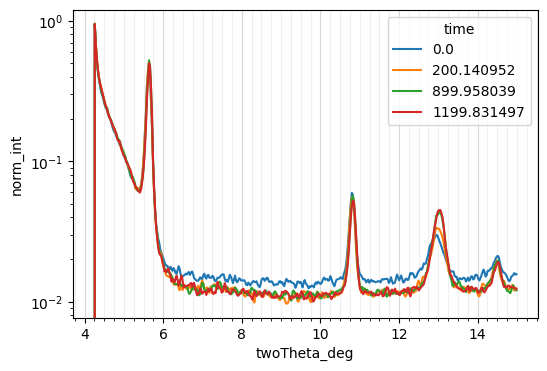

In [58]:
ds = da.to_dataset(name="intensity")

ds['norm_int'] = (ds['intensity'] - ds['intensity'].min()) / (ds['intensity'].max() - ds['intensity'].min())

twoTheta = np.rad2deg(2 * np.arcsin(ds["q_A^-1"] * 1.5418 / (4 * np.pi))).values
ds = ds.assign_coords({"twoTheta_deg": ("q_A^-1", twoTheta)}).swap_dims({"q_A^-1": "twoTheta_deg"})

fig, ax = plt.subplots(figsize=(6,4))
ds['norm_int']\
    .shift(twoTheta_deg=0)\
    .sel(time=[0, 200, 900, 1200], method='nearest')\
    .sel(twoTheta_deg=slice(None, 15))\
    .plot.line(x="twoTheta_deg", ax=ax)

# ax.set_ylim(None, 0.5)
ax.set_yscale('log')
# use minor ticks for x-axis
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.5)
ax.grid(True, which='minor', axis='x', linestyle='-', alpha=0.2)


In [4]:
%load_ext autoreload
%autoreload 2

shift_by_idx: 14
knot_xvals: [5.50748074 5.63768534 5.76789723 6.18462621 6.31487055 6.44512305]
[[Model]]
    (Model(voigt) + Model(spline_model, prefix='bkg_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 67
    # data points      = 39
    # variables        = 10
    chi-square         = 0.00102303
    reduced chi-square = 3.5277e-05
    Akaike info crit   = -391.393223
    Bayesian info crit = -374.757606
    R-squared          = 0.99810010
[[Variables]]
    amplitude:  0.07979066 +/- 0.00690449 (8.65%) (init = 0.09597654)
    center:     5.99734422 +/- 6.6147e-04 (0.01%) (init = 6.002298)
    sigma:      0.03552019 +/- 0.00490930 (13.82%) (init = 0.03385961)
    gamma:      0.03825135 +/- 0.00826136 (21.60%) (init = 0.03385961)
    fwhm:       0.13180395 +/- 0.00273316 (2.07%) == '1.0692*gamma+sqrt(0.8664*gamma**2+5.545083*sigma**2)'
    height:     0.45054115 +/- 0.01316764 (2.92%) == '(amplitude/(max(1e-15, sigma*sqrt(2*pi))))*real(wofz((1j*gamma)

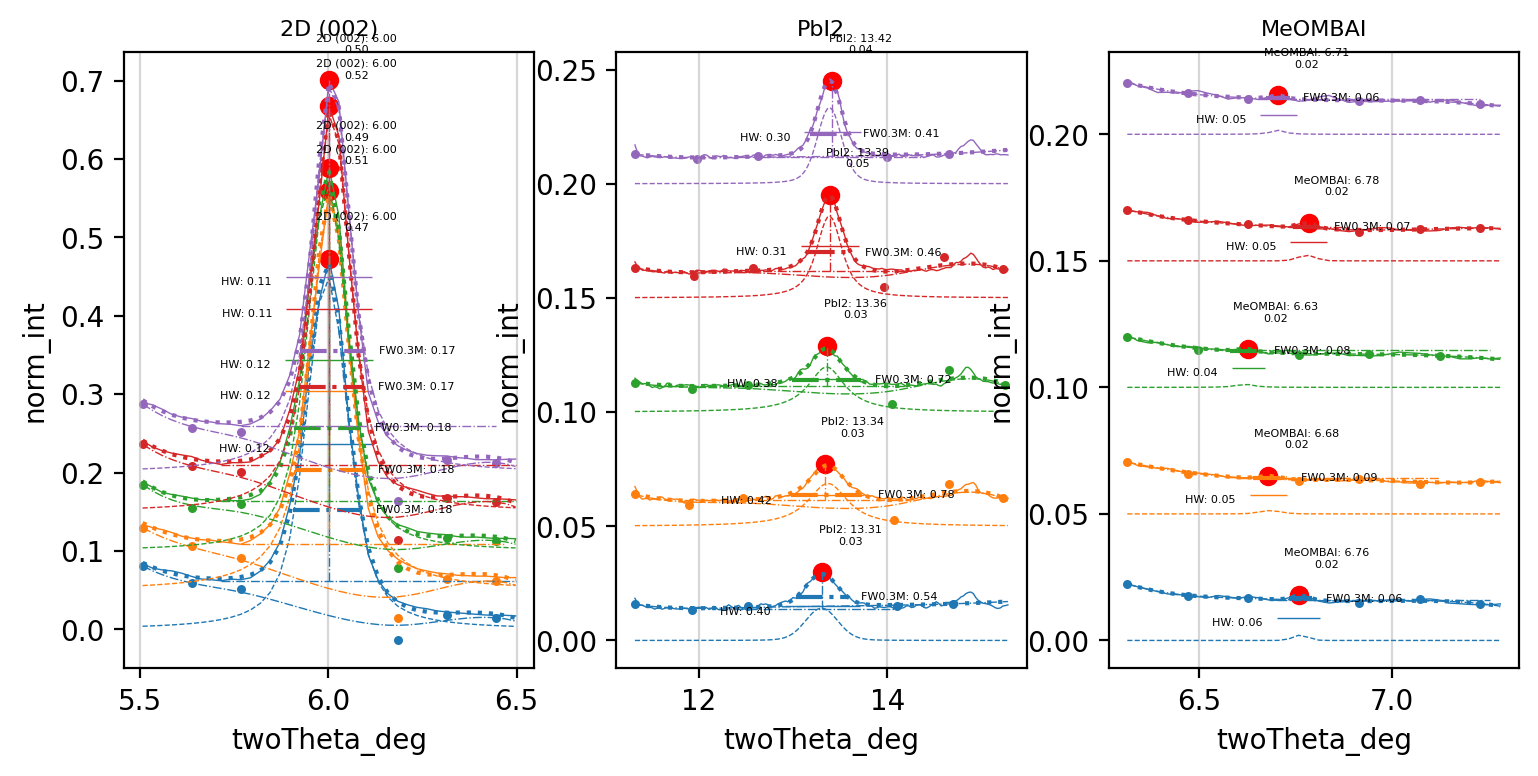

In [63]:
from analysis import baseline_correction, find_peaks_in_window, voigt_fit, voigt_profile_func
import numpy as np
from scipy.signal import peak_widths, peak_prominences
from vogit_width import voigt_width_at_height
from lmfit.models import VoigtModel, QuadraticModel, SplineModel


peaks_of_interest_with_phase = {
    "MBAI": [
        # (7.23, 2, (-1, 0), "2D (002)"), 
        (9.2, 1, (-1, 0), "1D (002)"), 
        (13.6, 2, (0, -1), "PbI2"),
        (22, 1, (0, -1), "MBAI"),
        (30.3, 2, (0, -1), "ITO")
    ],
    "ClMBAI": [
        (6.4, 0.5, (-1, 0), "2D (002)"),
        (11.6, 0.5, (0, -1), "2D (004)"),
        (27.9, 0.5, (0, -1), "2D (005)"),
        (14.9, 0.5, (0, -1), "2D (1-10)"),
        # (7.3, 0.5, (-1, 0), "ClMBAI"),
        (13.3, 2, (0, -1), "PbI2"),
        (30.3, 2, (0, -1), "ITO")
    ],
    "MeOMBAI": [
        (6.0, 0.5, (-1, 0), "2D (002)"),  # Backward: Start at End (-1) -> Go to Start (0). Window Increased.
        (13.3, 2.0, (0, -1), "PbI2"),     
        (6.8, 0.5, (-1, 0), "MeOMBAI")
    ]
}

peaks = peaks_of_interest_with_phase["MeOMBAI"]

fig, axes = plt.subplots(1, len(peaks), figsize=(9,4), dpi=200)

axes = axes.flatten() if len(peaks) > 1 else [axes]

times = [0, 60, 120, 1000, 1200]

ds_shifted = ds.sel(twoTheta_deg=slice(4.5, 27))

delta_twoTheta_deg = (ds.twoTheta_deg.values[-1] - ds.twoTheta_deg.values[0]) / (len(ds.twoTheta_deg) - 1)
shift_by_idx = int(0.4//delta_twoTheta_deg)
print(f"shift_by_idx: {shift_by_idx}")
ds_shifted = ds_shifted.shift(twoTheta_deg=shift_by_idx)

for i, (expected_cen, width, phase, label) in enumerate(peaks):


    ds_partial = ds_shifted['norm_int'].sel(twoTheta_deg=slice(expected_cen-width, expected_cen+width)).sel(time=times, method='nearest')
    # ds_partial = ds['norm_int'].sel(time=times, method='nearest')

    fit_res = []    

    for j, t in enumerate(ds_partial.time.values):
        da_t = ds_partial.sel(time=t)
        offest = 0.05*j
        # da_t = da_t + offest
        line = (da_t + offest).plot.line(x="twoTheta_deg", ax=axes[i], linewidth=0.5)[0]
        peaks_x, intensities, props = find_peaks_in_window(da_t, x="twoTheta_deg", target=expected_cen, window_size=width)
        # Only consider the most prominent peak
        peak_x = peaks_x[np.argmax(intensities)]
        intensity = np.max(intensities)
        props = props[np.argmax(intensities)]

        linecolor = line.get_color()

        half_width = props['half_widths']
        # plot the peak position and half-width
        axes[i].plot(peak_x, intensity + offest, 'ro')  # Peak position
        axes[i].hlines(intensity * 0.5 + offest, peak_x - half_width, peak_x + half_width, color=linecolor, linestyle='-', linewidth=0.5)  # Half-width
        axes[i].annotate(f"HW: {half_width:.2f}", xy=(peak_x - half_width, intensity * 0.5 + offest), 
                         xytext=(-5, 0), textcoords='offset points', ha='right', va="top", fontsize=4)
        
        

        # Only annotate if the peak is within the specified window
        if expected_cen - width <= peak_x <= expected_cen + width:
            axes[i].annotate(f"{label}: {peak_x:.2f}\n{intensity:.2f}", xy=(peak_x, intensity + offest), 
                             xytext=(10, 10), textcoords='offset points', ha='center', fontsize=4)
            prominences, lbs, rbs = peak_prominences(da_t.values, np.where(da_t.twoTheta_deg.values == peak_x)[0])

            axes[i].vlines(peak_x, intensity - prominences[0] + offest, intensity + offest, color=linecolor, linestyle='-.', linewidth=0.5)
            axes[i].hlines(intensity - prominences[0] + offest, da_t.twoTheta_deg.values[lbs[0]], da_t.twoTheta_deg.values[rbs[0]], color=linecolor, linestyle='-.', linewidth=0.5)
            
            
        lb, rb = peak_x - half_width * 1.2, peak_x + half_width* 1.2
        # lb, rb = da_t.twoTheta_deg.values[lbs[0]], da_t.twoTheta_deg.values[rbs[0]]
        da_voigt = da_t.sel(twoTheta_deg=slice(lb, rb))
        # use the invert selection for quadratic background        
        da_bkg = da_t.where(~((da_t.twoTheta_deg > lb) & (da_t.twoTheta_deg < rb)), drop=True)
        # da_quad = da_t.drop_sel(twoTheta_deg=slice(da_t.twoTheta_deg.values[lbs[0]], da_t.twoTheta_deg.values[rbs[0]]))
        
        # axes[i].plot(da_bkg.twoTheta_deg.values, da_bkg.values + offest, color='gray', marker='o')
        # plt.show()


        if any(da_voigt.isnull()):
            raise ValueError("Data contains NaN values, cannot fit.")

        voigt_mod = VoigtModel()
        voigt_pars = voigt_mod.guess(da_voigt.values, x=da_voigt.twoTheta_deg.values)
        voigt_pars['gamma'].vary = True
        voigt_pars['gamma'].min = 1e-9
        voigt_pars['sigma'].min = 1e-9
        voigt_pars['amplitude'].min = 1e-4


        # quadratic_mod = QuadraticModel()
        # quadratic_pars = quadratic_mod.guess(da_voigt.values, x=da_voigt.twoTheta_deg.values)

        # pars = voigt_pars + quadratic_pars
        # mod = voigt_mod + quadratic_mod

        pars = voigt_pars 
        knot_xvals = da_bkg.twoTheta_deg.values[::max(3, len(da_bkg)//5)]
        print(f"knot_xvals: {knot_xvals}")
        bkg = SplineModel(prefix='bkg_', xknots=knot_xvals)
        pars.update(bkg.guess(da_t.values, da_t.twoTheta_deg.values))
        mod = voigt_mod + bkg
        
        out = mod.fit(da_t.values, pars, x=da_t.twoTheta_deg.values)

        print(out.fit_report(min_correl=0.3))
       
        fit_x = da_t.twoTheta_deg.values
        # print(f"Fitted curve range: {fit_x[0]:.2f} to {fit_x[-1]:.2f}, fwhm: {fwhm:.2f}, fw10m: {fw10m:.2f}, cen: {cen:.2f}")
        # fwhm = min(fwhm, half_width*3)  # Limit FWHM to the window size to avoid unrealistic fits
        # fw10m = min(fw10m, half_width*10)  # Limit FW10M to the window size to avoid unrealistic fits        
        
        
        # print(f"Fitted curve range: {fit_x[0]:.2f} to {fit_x[-1]:.2f}, fwhm: {fwhm:.2f}, fw10m: {fw10m:.2f}, cen: {cen:.2f}")
        axes[i].plot(fit_x, out.best_fit + offest, color=linecolor, linestyle=':', label='Fit')
        comps = out.eval_components(x=fit_x)
        axes[i].plot(fit_x, comps['voigt'] + offest, '--', color=linecolor, linewidth=0.5)
        axes[i].plot(fit_x, comps['bkg_'] + offest, '-.', color=linecolor, linewidth=0.5)

        knot_yvals = np.array([o.value for o in out.params.values() if o.name.startswith('bkg')])
        axes[i].scatter(knot_xvals, knot_yvals + offest, c=linecolor, s=5)

        sigma, gamma = out.best_values['sigma'], out.best_values['gamma']

        fw3h = voigt_width_at_height(sigma, gamma, 0.3)

        da_bg = xr.DataArray(comps['bkg_'], coords={"twoTheta_deg": fit_x})
        cen = out.best_values['center']
        fw3h_y = da_bg.sel(twoTheta_deg=cen, method='nearest') + 0.3 * out.params['height'] + offest

        axes[i].hlines(fw3h_y, cen - fw3h/2, cen + fw3h/2, color=linecolor, linestyle='-.')
        axes[i].annotate(f"FW0.3M: {fw3h:.2f}", xy=(cen + fw3h/2, fw3h_y), 
                         xytext=(5, 0), textcoords='offset points', ha='left', va="center", fontsize=4)

    axes[i].set_title(f"{label}", fontsize=8)
    # print(f"Peak: {label}")
    # # t, amp, cen, sigma, gamma, slope, offset
    # for t, amp_fit, cen_fit, sigma_fit, gamma_fit, _, offset_fit, fwhm, fw10m in fit_res:
    #     print(f"Time: {t:>4.0f} s, Amplitude: {amp_fit:.2f}, Center: {cen_fit:.2f}, Sigma: {sigma_fit:.2f}, Gamma: {gamma_fit:.2f}, Offset: {offset_fit:.2f}, FWHM: {fwhm:.2f}, FW10M: {fw10m:.2f}")


for ax in axes:
    # ax.set_ylim(0, 1.0)
    # use minor ticks for x-axis
    # ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
    ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.5)
    ax.grid(True, which='minor', axis='x', linestyle='-', alpha=0.2)

print(out.params)
print(out.best_values)

In [6]:
from analysis import process_time_series_by_peak_lmfit

result_dfs = {}

## Configure peak tracking

Define peak positions (2θ in degrees), search windows, and tracking direction. The peaks_of_interest_with_phase mapping is selected based on the experiment name. Adjust global_shift_corrections if needed.

**About `result_dfs = {}` (cell above):**
- This dictionary stores the peak-tracking DataFrames for each experiment name.
- If you re-run the analysis cell without re-running `result_dfs = {}`, previous results remain and will still be plotted.
- To clear previous runs, re-run `result_dfs = {}` (or restart the kernel).

In [47]:
# --- Configuration ---
# Format: (Center, Window, (Start_Index, Stop_Index), Name)
# Start_Index: Where to start tracking
# Stop_Index: Where to end tracking (Inclusive). 
# Direction is implied: (0, -1) = Forward, (-1, 0) = Backward.

peaks_of_interest_with_phase = {
    "MBAI": [
        (6.9, 2, (-1, 0), "2D (002)"), 
        (13.3, 2, (0, -1), "PbI2"),
        (22, 1, (0, -1), "MBAI")  # Example of an additional peak
    ],
    "ClMBAI": [
        (6.4, 1, (-1, 25), "2D (002)"),
        (7.3, 0.5, (-1, 0), "ClMBAI"),
        (13.3, 2, (0, -1), "PbI2"),
        (30.2, 2, (0, -1), "ITO")
    ],
    "p?MeOMBAI": [
        (6.1, 0.8, (-1, 0), "2D (002)"),  # Backward: Start at End (-1) -> Go to Start (0). Window Increased.
        (13.3, 2.0, (0, -1), "PbI2"),     
        (7.0, 0.8, (-1, 0), "MeOMBAI")
    ]
}

global_shift_corrections = {
    "1p5M_pMeOMBAI_1": -5,
    "insitu_0p5M_MeOMBAI_7": 3,
    "insitu_1p0M_MeOMBAI_6": 3
}


output_base_dir = da_file.parent / "peak_tracking_results"

exp_name = da_file.stem

print(f"\n=== Processing Experiment: {exp_name} ===")

# 1. Select and Shift Data
time_series_da = ds["norm_int"].sel(twoTheta_deg=slice(5.5, 35)).dropna(dim="time")

shift = global_shift_corrections.get(exp_name, 0)
if shift != 0:
    time_series_da = time_series_da.shift(twoTheta_deg=shift)

# 2. Get Peaks Definition
current_peaks_def = []
for key, val in peaks_of_interest_with_phase.items():
    # if re.search(f"{key}_", exp_name, re.IGNORECASE):
    if exp_name.startswith(key):
        current_peaks_def = val
        break
print(f"Current Peaks Definition: {current_peaks_def}")

# 3. Run Peak Tracking
df_evolution = process_time_series_by_peak_lmfit(
    time_series_da,
    peaks_definition=current_peaks_def,
    sample_name=exp_name,
    output_dir=output_base_dir,
    debug=True,
    integration_bounds_by_fwm={"height": 0.25, "multiplier": 2},
    substract_baseline=True,
    # Add baseline_kwargs if correction is needed, e.g., method='asls', lam=5e3
)

if not df_evolution.empty:
    result_dfs[exp_name] = df_evolution
    print("\n--- Evolution DataFrame Head ---")
    print(df_evolution.head())
else:
    print("  No effective peak data found.")


=== Processing Experiment: ClMBAI_0M5_1 004910 Images ===
Current Peaks Definition: [(6.4, 1, (-1, 25), '2D (002)'), (7.3, 0.5, (-1, 0), 'ClMBAI'), (13.3, 2, (0, -1), 'PbI2'), (30.2, 2, (0, -1), 'ITO')]


c:\Users\yrliu98\Documents\als-xrd-12-3-2\.venv\Lib\site-packages\lmfit\models.py:243: RankWarning: Polyfit may be poorly conditioned
  sval, oval = np.polyfit(x, data, 1)
c:\Users\yrliu98\Documents\als-xrd-12-3-2\analysis.py:934: RuntimeWarning: invalid value encountered in scalar divide
  delta_x = (da_peak.twoTheta_deg.values[-1] - da_peak.twoTheta_deg.values[0])/(len(da_peak.twoTheta_deg) - 1)
c:\Users\yrliu98\Documents\als-xrd-12-3-2\analysis.py:934: RuntimeWarning: invalid value encountered in scalar divide
  delta_x = (da_peak.twoTheta_deg.values[-1] - da_peak.twoTheta_deg.values[0])/(len(da_peak.twoTheta_deg) - 1)
c:\Users\yrliu98\Documents\als-xrd-12-3-2\analysis.py:934: RuntimeWarning: invalid value encountered in scalar divide
  delta_x = (da_peak.twoTheta_deg.values[-1] - da_peak.twoTheta_deg.values[0])/(len(da_peak.twoTheta_deg) - 1)



--- Evolution DataFrame Head ---
             Area                            BackgroundArea                   \
PeakName 2D (002) ClMBAI       ITO      PbI2       2D (002) ClMBAI       ITO   
Time                                                                           
0.000000      NaN    NaN  0.026601  0.047269            NaN    NaN  0.026763   
1.433701      NaN    NaN  0.029357  0.047789            NaN    NaN  0.026145   
2.777549      NaN    NaN  0.025458  0.046717            NaN    NaN  0.030729   
4.154341      NaN    NaN  0.019307  0.044897            NaN    NaN  0.031217   
5.464243      NaN    NaN  0.019475  0.041095            NaN    NaN  0.029336   

                    
PeakName      PbI2  
Time                
0.000000  0.008334  
1.433701  0.007639  
2.777549  0.009071  
4.154341  0.008984  
5.464243  0.009231  


In [48]:
result_dfs[exp_name] = df_evolution["Area"]

## Visualize peak evolution

The plot below normalizes each peak trace per experiment and shows a smoothed trend for easier comparison across time.

In [14]:
print(final_merged_df.index)

Index([        0.0,    1.433701,    2.777549,    4.154341,    5.464243,
          6.809088,     8.14894,    9.539712,   10.898533,   12.281317,
       ...
       1254.256289, 1255.719945, 1257.217545, 1258.696174, 1260.244693,
       1261.922004, 1263.477512, 1265.081941, 1266.587528, 1268.341717],
      dtype='float64', name='Time', length=873)


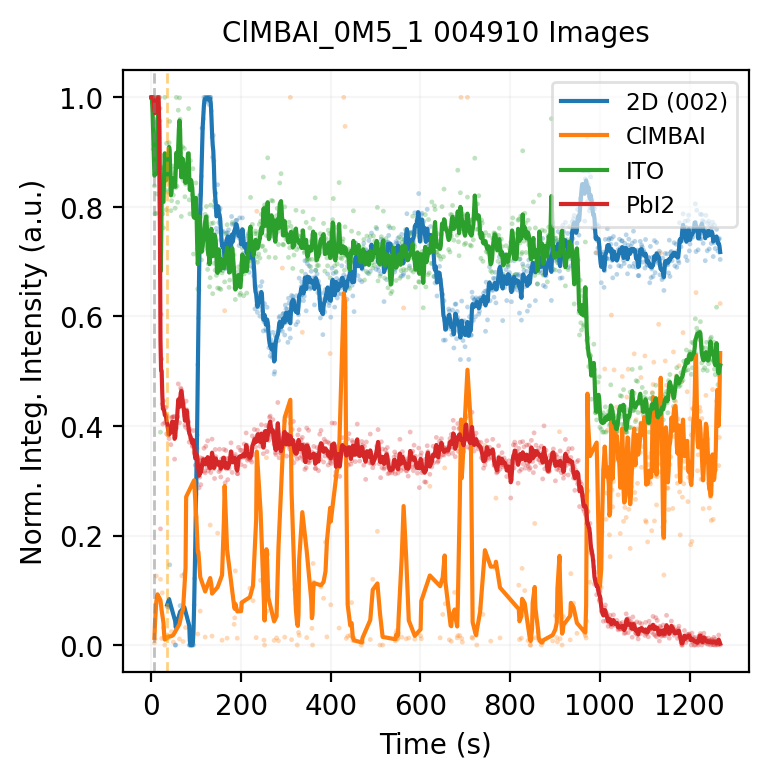

In [55]:
import matplotlib.pyplot as plt
import re
import numpy as np
from scipy.ndimage import gaussian_filter1d

merged_dfs = result_dfs

# Create a single merged DataFrame for global inspection
final_merged_df = pd.concat(merged_dfs, axis=1)
final_merged_df.columns.names = ['experiment', 'phase']

# Cell 14: Visualization of Peak Evolution
# -------------------------------------------------------------------------

# Plot all experiments in a grid (4 columns, N rows)
all_experiments = sorted(merged_dfs.keys())
num_exps = len(all_experiments)
if num_exps == 0:
    print("No experiments to plot. Run the analysis cell first.")
else:
    ncols = 3
    nrows = int(np.ceil(num_exps / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(max(6, ncols * 3.5), max(4, nrows * 3.2)), sharey=True, dpi=200)
    axes = np.atleast_1d(axes).ravel()

    # Plot each experiment
    for i, exp_name in enumerate(all_experiments):
        ax = axes[i]
        df = merged_dfs[exp_name]
        
        # Plot each phase found in the dataframe
        for column in df.columns:
            # Get data and drop NaNs (some peaks might not be found in all frames)
            series = df[column].dropna()
            if series.empty:
                continue

            # Filtering and Normalization
            # Remove extreme outliers for better plotting scale
            lower_bound = np.percentile(series, 1)
            upper_bound = np.percentile(series, 99)
            clipped = series.clip(lower_bound, upper_bound)
            
            # Min-Max Normalize
            if column == 'ITO':
                norm_data = clipped/clipped.max()
            else:
                denom = (clipped.max() - clipped.min())
                if denom == 0:
                    denom = 1
                norm_data = (clipped - clipped.min()) / denom
            
            
            ax.scatter(norm_data.index, norm_data, alpha=0.3, s=3, edgecolors='none')
            
            # Smoothing
            # Sigma=1 roughly smooths over +/- 1 second if data is 1s resolution
            smooth_data = gaussian_filter1d(norm_data, sigma=1)
            ax.plot(norm_data.index, smooth_data, linewidth=1.5, label=column)
        
        # Formatting
        clean_title = exp_name.replace("p", ".", 1).replace("insitu_", "")
        ax.set_title(clean_title, y=1.02, fontsize=10)
        ax.set_xlabel("Time (s)")
        
        if i % ncols == 0:
            ax.set_ylabel("Norm. Integ. Intensity (a.u.)")
        
        # Markers for experiment events
        ax.axvline(5, color='gray', linestyle='--', alpha=0.5, linewidth=1) # Dispense
        ax.axvline(35, color='orange', linestyle='--', alpha=0.5, linewidth=1) # Heating
        
        ax.legend(fontsize='small', framealpha=0.6)
        ax.grid(True, alpha=0.1)
        # ax.set_xlim(80, 200)

    # Hide any unused axes
    for j in range(num_exps, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()